# 1. Random Sampling and Sample Bias

**Population** adalah keseluruhan kelompok yang ingin dipahami, sedangkan **sample** adalah subset yang digunakan untuk memperoleh informasi tentang population.

**Simple random sample** diperoleh melalui random sampling tanpa stratifikasi.

**Sample bias** terjadi ketika sample salah merepresentasikan population secara sistematis.

### Size Versus Quality

Sample yang lebih kecil tetapi dipilih dengan baik dapat lebih berguna daripada dataset yang sangat besar tetapi biased atau sulit diperiksa. Big data tetap penting untuk kasus tertentu, misalnya data yang sangat sparse.

### Sample Mean Versus Population Mean

- $\bar{x}$ = sample mean
- $\mu$ = population mean

Sample diamati langsung, sedangkan population mean sering diinferensikan dari sample.

# 2. Sampling Distribution of a Statistic

**Sampling distribution** adalah distribusi nilai suatu sample statistic yang diperoleh dari banyak sample.

- **data distribution**: distribusi individual data points,
- **sampling distribution**: distribusi sample statistic.

Sampling distribution dari mean cenderung lebih regular dan lebih sempit daripada data distribution ketika sample size meningkat.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.utils import resample
from google.colab import files

uploaded = files.upload()

loans_income = pd.read_csv('loans_income.csv').squeeze()

Saving loans_income.csv to loans_income (1).csv
Saving sp500_data.csv to sp500_data.csv


In [3]:
sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})
sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})
sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])

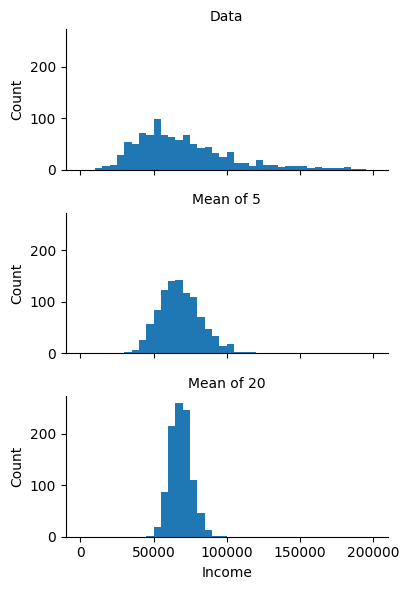

In [4]:
g = sns.FacetGrid(results, col='type', col_wrap=1, height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

# 3. Central Limit Theorem

**Central Limit Theorem (CLT)** menyatakan bahwa mean dari banyak sample akan cenderung menyerupai bell-shaped normal curve ketika sample size cukup besar dan penyimpangan population dari normalitas tidak terlalu besar.

CLT membantu menjelaskan mengapa pendekatan normal dapat digunakan untuk sampling distributions.

# 4. Standard Error

**Standard error (SE)** mengukur variability sebuah sample statistic antar-sample.

Untuk sample mean:

$$SE = \frac{s}{\sqrt{n}}$$

**Square-root of n rule**: untuk mengurangi SE menjadi setengah, sample size perlu dinaikkan sekitar empat kali.

Jangan tertukar:
- standard deviation → variability individual data points,
- standard error → variability sample statistic.

In [6]:
se = loans_income.std() / (len(loans_income) ** 0.5)
se

147.00821129152416

# 5. The Bootstrap

**Bootstrap** adalah pengambilan sample berulang **with replacement dari observed data** untuk mengestimasi sampling distribution.

Algoritmanya:
1. draw value,
2. replace value,
3. ulangi hingga sample size $n$,
4. hitung statistic,
5. ulangi $R$ kali,
6. gunakan hasil untuk standard error, histogram/boxplot, atau confidence interval.

Bootstrap tidak menciptakan data baru dan tidak memperbaiki sample size yang kecil.

In [7]:
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)

print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: 62000.0
bias: -80.64800000000105
std. error: 232.9830104947132


Text(0, 0.5, 'Frequency')

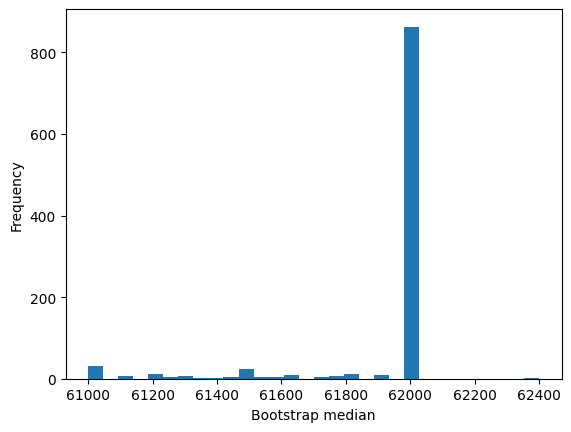

In [8]:
ax = results.plot.hist(bins=30)
ax.set_xlabel('Bootstrap median')
ax.set_ylabel('Frequency')

### Multivariate Bootstrap

Bootstrap juga dapat diterapkan pada multivariate data dengan **row sebagai unit sampling**.

# 6. Confidence Intervals

Confidence interval menyajikan estimate sebagai **range**, bukan satu angka.

Confidence level adalah coverage level yang diharapkan dari prosedur interval jika prosedur yang sama diulang.

### Bootstrap confidence interval
1. Draw sample size $n$ with replacement.
2. Hitung statistic.
3. Ulangi $R$ kali.
4. Untuk confidence level $x\%$, trim $(100-x)/2\%$ dari masing-masing ekor.
5. Titik trim menjadi interval endpoints.

Semakin tinggi confidence level → interval lebih lebar.
Semakin kecil sample → interval lebih lebar.

# 7. Normal Distribution

Normal distribution berbentuk bell curve dengan parameter mean $\mu$ dan standard deviation $\sigma$.

Dalam normal distribution:
- sekitar 68% berada dalam ±1 SD,
- sekitar 95% berada dalam ±2 SD.



# 8. Standard Normal and QQ-Plots

**Standard normal** memiliki mean 0 dan standard deviation 1.

Standardization:

$$z = \frac{x-\bar{x}}{s}$$

QQ-Plot digunakan untuk melihat kedekatan sample terhadap specified distribution. Jika titik mengikuti garis diagonal, sample mendekati distribution tersebut.

((array([-2.46203784, -2.12570747, -1.93122778, -1.79044653, -1.67819304,
         -1.58381122, -1.50174123, -1.42869743, -1.36256869, -1.30191411,
         -1.24570419, -1.19317644, -1.14374949, -1.09696931, -1.05247413,
         -1.00997067, -0.96921765, -0.93001393, -0.89218993, -0.85560121,
         -0.82012357, -0.78564937, -0.75208458, -0.71934648, -0.68736185,
         -0.65606548, -0.62539893, -0.59530962, -0.56574992, -0.53667655,
         -0.50804994, -0.47983378, -0.45199463, -0.42450149, -0.39732558,
         -0.37044003, -0.34381966, -0.31744076, -0.29128096, -0.26531902,
         -0.23953472, -0.21390872, -0.18842244, -0.16305799, -0.13779803,
         -0.1126257 , -0.08752455, -0.06247843, -0.03747145, -0.01248789,
          0.01248789,  0.03747145,  0.06247843,  0.08752455,  0.1126257 ,
          0.13779803,  0.16305799,  0.18842244,  0.21390872,  0.23953472,
          0.26531902,  0.29128096,  0.31744076,  0.34381966,  0.37044003,
          0.39732558,  0.42450149,  0.

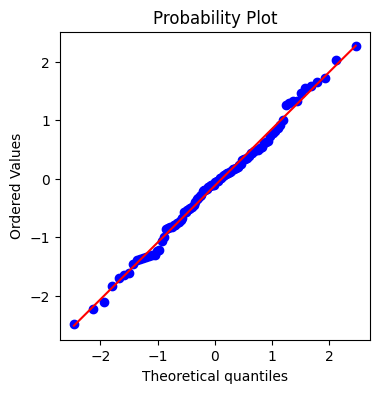

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))
norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax)

# 9. Long-Tailed Distributions

**Tail** adalah bagian panjang dan sempit dari frequency distribution tempat extreme values muncul dengan frequency rendah.

**Skew** terjadi ketika salah satu tail lebih panjang daripada tail lainnya.


((array([-3.33278964, -3.07756454, -2.93575124, ...,  2.93575124,
          3.07756454,  3.33278964]),
  array([-6.60529819, -6.09667121, -5.40220961, ...,  5.12547859,
          5.87072271,  6.03787   ])),
 (np.float64(1.4823778663727092),
  np.float64(0.0015561067366313861),
  np.float64(0.9941828221936319)))

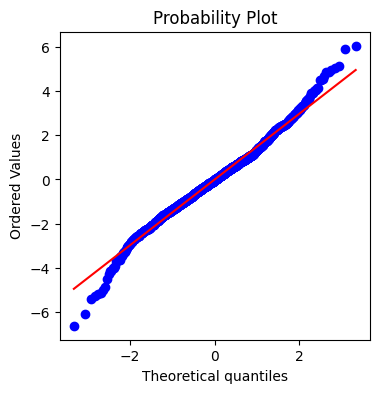

In [14]:
sp500_px = pd.read_csv('sp500_data.csv', index_col=0)

nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx > 0]))

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)

# 10. Student's t-Distribution

Student's t-distribution menyerupai normal distribution tetapi memiliki tails yang lebih tebal dan panjang.

t-distribution merupakan keluarga distribution yang berbeda menurut **degrees of freedom**. Semakin besar sample size/degrees of freedom, bentuknya semakin mendekati normal.

# 11. Binomial Distribution

Binomial outcomes adalah **yes/no**, **0/1**, atau binary outcomes.

Binomial distribution menggambarkan jumlah successes $x$ dalam $n$ trials dengan probability success $p$.

$$P(X=x)=\binom{n}{x}p^x(1-p)^{n-x}$$

Mean:

$$E(X)=np$$

Variance:

$$Var(X)=np(1-p)$$

In [15]:
stats.binom.pmf(2, n=5, p=0.1)

np.float64(0.07289999999999992)

In [16]:
stats.binom.cdf(2, n=5, p=0.1)

np.float64(0.99144)

### Interpretasi

`pmf` memberikan probability **exactly** sejumlah successes.

`cdf` memberikan probability sejumlah successes **atau kurang**.


# 12. Chi-Square Distribution

Chi-square distribution digunakan untuk mengukur **departure from expectation**, terutama untuk category counts.

Chi-square statistic:

$$\chi^2=\sum\frac{(Observed-Expected)^2}{Expected}$$

Semakin besar perbedaan observed dan expected, semakin besar statistic.


# 13. F-Distribution

F-distribution digunakan pada eksperimen dan linear models dengan measured/continuous data.

F-statistic membandingkan variability antar group means dengan variability di dalam group:

$$F=\frac{\text{variation between groups}}
{\text{variation within groups}}$$


# 14. Poisson and Related Distributions

Poisson dan related distributions digunakan untuk proses yang menghasilkan events secara random dengan overall rate.

**Lambda ($\lambda$)** = event rate per unit time atau space.

## Poisson Distribution

Poisson distribution adalah distribution dari jumlah events pada unit waktu atau ruang.

Mean:

$$E(X)=\lambda$$

Variance:

$$Var(X)=\lambda$$


In [17]:
stats.poisson.rvs(2, size=100)

array([2, 0, 3, 2, 3, 2, 5, 1, 1, 1, 3, 2, 5, 1, 3, 2, 3, 0, 3, 0, 5, 3,
       2, 1, 0, 2, 1, 0, 1, 1, 4, 1, 1, 2, 0, 3, 1, 1, 0, 0, 1, 2, 2, 0,
       2, 1, 3, 3, 1, 0, 0, 4, 3, 4, 2, 1, 4, 3, 1, 4, 3, 5, 0, 1, 3, 1,
       5, 3, 2, 2, 2, 2, 2, 3, 2, 0, 1, 3, 1, 3, 0, 0, 1, 1, 7, 2, 1, 3,
       3, 1, 2, 2, 2, 0, 1, 0, 2, 1, 5, 0])

## Exponential Distribution

Exponential distribution digunakan untuk **time/distance between events**, misalnya waktu antara website visits atau cars arriving.

## Weibull Distribution

Weibull adalah generalized version dari exponential distribution, dengan event rate yang dapat berubah sepanjang waktu.
